# Implementación del FOA con distribución Gamma

Ilustramos la implementación numérica del FOA restringiendo la atención a la clase de
contratos afines $w(x)=w_0+\beta x$ con $(w_0,\beta)\in\mathbb R\times(0,1]$. Tales contratos
son no decrecientes y cóncavos, de donde $w\in W_{\mathrm{conc}}$, y por lo tanto el valor
calculado es una cota inferior del valor del problema original.

Suponemos que $X\mid a$ tiene distribución gamma de forma fija con parámetros $(\kappa,a)$,
$a\in A=[\underline a,\overline a]$ con $\underline a>0$ y $\mathcal X=(0,\infty)$. Entonces
$\mathbb E[X\mid a]=\kappa a$ y, por el Supuesto A4,
$$\phi_1(\alpha)=\gamma^{-1}\bigl(\kappa,\alpha\Gamma(\kappa)\bigr),\qquad \phi_2\equiv0 .$$

El Agente tiene utilidad CARA normalizada y costo del esfuerzo cuadrático,
$$u(w)=\frac{1-e^{-\eta w}}{\eta},\qquad
u^{-1}(v)=-\frac1\eta\log(1-\eta v),\qquad
c(a)=\frac\theta2 a^2 ,$$
donde $\eta>0$ es el coeficiente de aversión absoluta al riesgo y $\theta>0$ el parámetro del
costo. El Principal es neutral al riesgo, con utilidad de Bernoulli $U_P(x,w)=x-w$, de modo
que su utilidad esperada es
$$\mathbb E^{a}\bigl[X-w(X)\bigr]=(1-\beta)\kappa a-w_0 .$$

## 1. Parámetros

| Símbolo | Nombre | Valor |
|---|---|---|
| $A=[\underline a,\overline a]$ | conjunto de acciones admisibles | $[1/20,\,7/2]$ |
| $\kappa$ | parámetro de forma de la gamma | $2$ |
| $\eta$ | aversión absoluta al riesgo | $1/2$ |
| $\theta$ | parámetro del costo | $1/5$ |
| $R_0$ | utilidad de reserva | $1/2$ |
| $\alpha$ | nivel de la restricción en cuantil | $1/10$ |

La inversa $u^{-1}$ está bien definida en $A$ si y sólo si
$\eta\bigl(R_0+\tfrac\theta2\overline a^{\,2}\bigr)<1$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaincinv
from scipy.optimize import brentq, minimize_scalar
from scipy.stats import gamma as gamma_dist

plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': .25, 'figure.dpi': 120})
COL = dict(main='#1f4e79', alt='#c0392b', third='#2e7d32', grey='#7f7f7f')

PAR = dict(kappa=2.0, eta=0.5, theta=0.2, R0=0.5, alpha=0.10, a_min=0.05, a_max=3.5)

def phi1(alpha, kappa):
    "Cuantil alpha de Gamma(kappa, escala 1) = gamma^{-1}(kappa, alpha*Gamma(kappa))."
    return gammaincinv(kappa, alpha)

def u(w, eta):      return (1.0 - np.exp(-eta * w)) / eta
def u_inv(v, eta):  return -np.log1p(-eta * v) / eta
def cost(a, theta): return 0.5 * theta * a ** 2
def dom_ok(a, p):   return p['eta'] * (p['R0'] + cost(a, p['theta'])) < 1.0

p = PAR
print(f"phi1(alpha) = {phi1(p['alpha'], p['kappa']):.6f}")
print(f"eta(R0 + c(a_max)) = {p['eta']*(p['R0']+cost(p['a_max'], p['theta'])):.4f} < 1"
      f"  ->  {dom_ok(p['a_max'], p)}")

phi1(alpha) = 0.531812
eta(R0 + c(a_max)) = 0.8625 < 1  ->  True


## 2. Modelo

La función generadora de momentos de la gamma da
$\mathbb E\bigl[e^{-\eta\beta X}\mid a\bigr]=(1+\eta\beta a)^{-\kappa}$, de donde
$$\Phi_w(a)=\frac1\eta\Bigl(1-e^{-\eta w_0}(1+\eta\beta a)^{-\kappa}\Bigr)-\frac\theta2a^2,
\qquad
\Phi_w'(a)=\kappa\beta\,e^{-\eta w_0}(1+\eta\beta a)^{-\kappa-1}-\theta a .$$

Como $\Phi_w''(a)=-\kappa(\kappa+1)\eta\beta^2e^{-\eta w_0}(1+\eta\beta a)^{-\kappa-2}-\theta<0$,
la aplicación $a\mapsto\Phi_w(a)$ es estrictamente cóncava y $\Phi_w'(a)=0$ caracteriza el
maximizador global del problema del Agente.

La condición de primer orden despeja el salario base:
$$\Phi_w'(a)=0
\iff
w_0=-\frac1\eta\log\!\left(\frac{\theta a(1+\eta\beta a)^{\kappa+1}}{\kappa\beta}\right).$$

Sustituyendo este valor en la restricción de participación se obtiene la desigualdad
$$\frac{\theta a(1+\eta\beta a)^{\kappa+1}}{\kappa\beta}
\;\le\;\Bigl(1-\eta\bigl(R_0+\tfrac\theta2a^2\bigr)\Bigr)e^{\eta\beta\phi_1(\alpha)a},$$
que se evalúa en escala logarítmica por estabilidad numérica.

In [3]:
def Phi(a, w0, beta, p):
    k, eta = p['kappa'], p['eta']
    return (1.0 - np.exp(-eta*w0) * (1.0 + eta*beta*a)**(-k)) / eta - cost(a, p['theta'])

def dPhi(a, w0, beta, p):
    k, eta = p['kappa'], p['eta']
    return k*beta*np.exp(-eta*w0) * (1.0 + eta*beta*a)**(-k-1) - p['theta']*a

def w0(a, beta, p):
    "Salario base despejado de Phi_w'(a) = 0."
    k, eta = p['kappa'], p['eta']
    return -np.log(p['theta']*a*(1.0 + eta*beta*a)**(k+1) / (k*beta)) / eta

def restriccion(beta, a, p):
    "log(lado derecho) - log(lado izquierdo). La participacion se cumple si es >= 0."
    k, eta, th = p['kappa'], p['eta'], p['theta']
    lhs = np.log(th*a) + (k+1)*np.log1p(eta*beta*a) - np.log(k*beta)
    rhs = np.log1p(-eta*(p['R0'] + cost(a, th))) + eta*beta*phi1(p['alpha'], k)*a
    return rhs - lhs

## 3. Reducción 

La utilidad esperada del Principal tiende a $+\infty$ cuando $\beta\downarrow0$, de modo que
la restricción de participación se activa en el óptimo. Con ella activa,
$w_0=u^{-1}\bigl(R_0+c(a)\bigr)-\beta\phi_1(\alpha)a$ y la utilidad esperada del Principal
queda
$$\mathbb E^{a}\bigl[X-w(X)\bigr]
=\kappa a-\beta a\bigl(\kappa-\phi_1(\alpha)\bigr)-u^{-1}\!\bigl(R_0+\tfrac\theta2a^2\bigr),$$
estrictamente decreciente en $\beta$ porque $\phi_1(\alpha)<\kappa$. Para cada $a$ basta
entonces el menor $\beta$ admisible, y el problema se reduce a una maximización escalar en
$a$.

In [4]:
def beta_min(a, p, n_scan=2000):
    "Menor beta en (0,1] compatible con la incentivo-compatibilidad y la participacion."
    if not dom_ok(a, p):
        return None
    grid = np.linspace(1e-9, 1.0, n_scan)[1:]
    g = restriccion(grid, a, p)
    idx = np.where(np.sign(g[:-1]) != np.sign(g[1:]))[0]
    if len(idx) == 0:
        return None
    i = idx[0]
    return brentq(restriccion, grid[i], grid[i+1], args=(a, p), xtol=1e-14, rtol=1e-14)

def EUP(a, p):
    "Utilidad esperada del Principal en el optimo restringido, dado a."
    b = beta_min(a, p)
    if b is None:
        return -np.inf, None, None
    return (1.0 - b)*p['kappa']*a - w0(a, b, p), b, w0(a, b, p)

def solve(p, n_a=1500):
    ag = np.linspace(p['a_min'], p['a_max'], n_a)
    vals = np.array([EUP(a, p)[0] for a in ag])
    i = int(np.nanargmax(vals))
    res = minimize_scalar(lambda a: -EUP(a, p)[0],
                          bounds=(ag[max(i-1, 0)], ag[min(i+1, n_a-1)]),
                          method='bounded', options=dict(xatol=1e-12))
    V, b, wb = EUP(res.x, p)
    return dict(a=res.x, beta=b, w0=wb, value=V, a_grid=ag, value_grid=vals)

def first_best(p, n_a=200000):
    "Sin incentivo-compatibilidad: salario constante w = u^{-1}(R0 + c(a))."
    ag = np.linspace(p['a_min'], p['a_max'], n_a)
    ok = np.array([dom_ok(a, p) for a in ag])
    vals = np.where(ok, p['kappa']*ag - u_inv(p['R0'] + cost(ag, p['theta']), p['eta']), -np.inf)
    i = int(np.argmax(vals))
    return dict(a=ag[i], w=u_inv(p['R0'] + cost(ag[i], p['theta']), p['eta']), value=vals[i])

## 4. Solución

In [5]:
sol = solve(p)
fb  = first_best(p)
f1  = phi1(p['alpha'], p['kappa'])

print('--- Segundo optimo (incentivo-compatibilidad + participacion en cuantil) ---')
print(f"a*    = {sol['a']:.6f}")
print(f"beta* = {sol['beta']:.6f}")
print(f"w0*   = {sol['w0']:.6f}")
print(f"utilidad esperada del Principal = {sol['value']:.6f}")

print('\n--- Primer optimo (salario constante) ---')
print(f"a  = {fb['a']:.6f}   w = {fb['w']:.6f}")
print(f"utilidad esperada del Principal = {fb['value']:.6f}")

fin = np.isfinite(sol['value_grid'])
a_lo, a_hi = sol['a_grid'][fin].min(), sol['a_grid'][fin].max()
print(f"\nrango factible de a: [{a_lo:.4f}, {a_hi:.4f}]  ->  a* interior: {a_lo < sol['a'] < a_hi}")

--- Segundo optimo (incentivo-compatibilidad + participacion en cuantil) ---
a*    = 1.297793
beta* = 0.299473
w0*   = 0.606881
utilidad esperada del Principal = 1.211397

--- Primer optimo (salario constante) ---
a  = 3.000006   w = 2.407958
utilidad esperada del Principal = 3.592054

rango factible de a: [0.0500, 1.6127]  ->  a* interior: True


### Iteraciones sobre $\alpha$ y $\kappa$

Repetimos la resolución variando el nivel $\alpha$ de la restricción en cuantil y el
parámetro de forma $\kappa$, dejando el resto de los parámetros fijos.

In [6]:
def tabla(key, valores, p):
    print(f"{key:>7} {'phi1':>9} {'a*':>10} {'beta*':>10} {'w0*':>10} {'E[X-w(X)]':>12}")
    print('-'*62)
    filas = []
    for v in valores:
        q = dict(p); q[key] = v
        try:
            s = solve(q, n_a=900)
            f = phi1(q['alpha'], q['kappa'])
            print(f"{v:>7.3g} {f:>9.4f} {s['a']:>10.6f} {s['beta']:>10.6f} "
                  f"{s['w0']:>10.6f} {s['value']:>12.6f}")
            filas.append((v, s['a'], s['beta'], s['w0'], s['value']))
        except Exception:
            print(f"{v:>7.3g}   sin solucion factible")
    return np.array(filas)

print('Variando alpha (kappa = 2):')
Ta = tabla('alpha', [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40], p)
print('\nVariando kappa (alpha = 1/10):')
Tk = tabla('kappa', [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0], p)

Variando alpha (kappa = 2):
  alpha      phi1         a*      beta*        w0*    E[X-w(X)]
--------------------------------------------------------------
   0.01    0.1486   1.172633   0.256128   0.723044     1.021532
  0.025    0.2422   1.200022   0.265237   0.700131     1.063333
   0.05    0.3554   1.235636   0.277390   0.668258     1.117509
    0.1    0.5318   1.297793   0.299473   0.606881     1.211397
   0.15    0.6832   1.359280   0.322470   0.538780     1.303125
    0.2    0.8244   1.425618   0.348641   0.456809     1.400368
    0.3    1.0973   1.592566   0.421168   0.209785     1.633872
    0.4    1.3764   1.881293   0.568499  -0.358490     1.982050

Variando kappa (alpha = 1/10):
  kappa      phi1         a*      beta*        w0*    E[X-w(X)]
--------------------------------------------------------------
      1    0.1054   0.871025   0.310921   0.650636    -0.050431
    1.5    0.2922   1.117171   0.305628   0.649342     0.514256
      2    0.5318   1.297793   0.299473   0.60

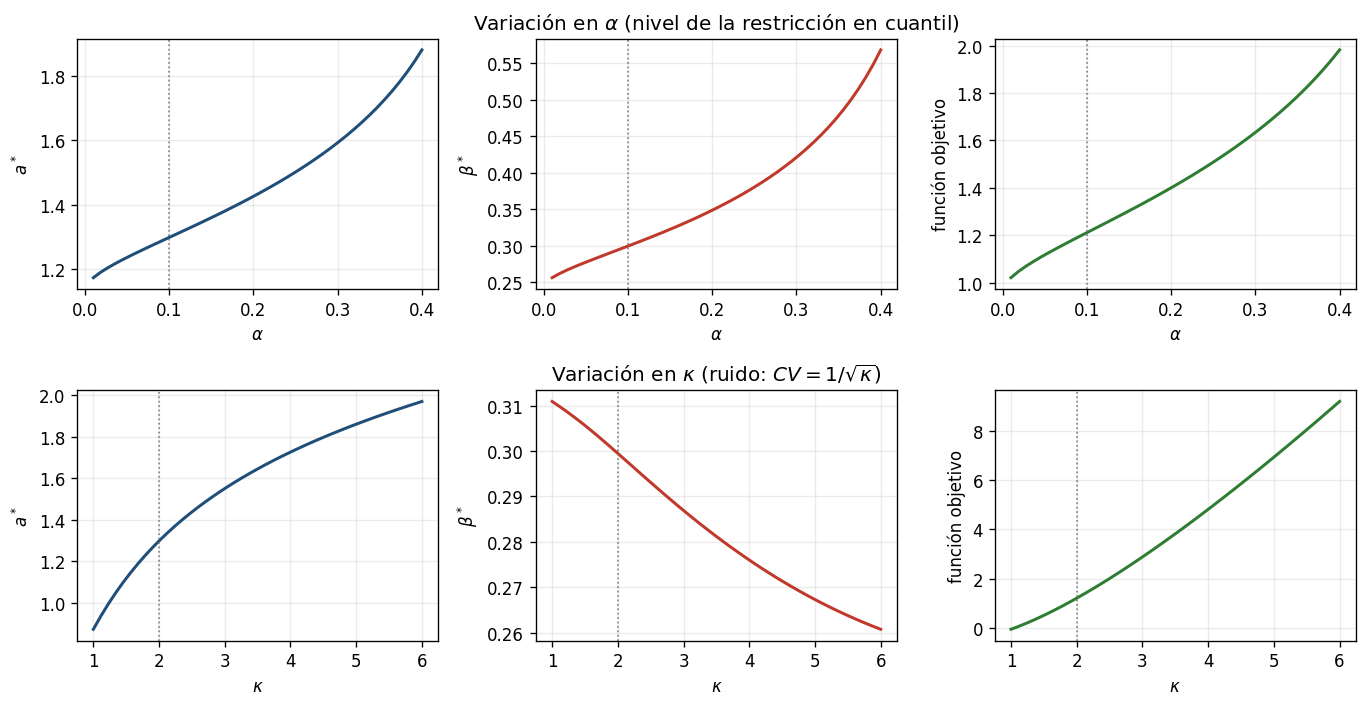

In [7]:
alphas = np.linspace(0.01, 0.40, 45)
kappas = np.linspace(1.0, 6.0, 45)
Sa = np.array([[v] + [solve({**p, 'alpha': v}, n_a=700)[k] for k in ('a', 'beta', 'value')]
               for v in alphas])
Sk = np.array([[v] + [solve({**p, 'kappa': v}, n_a=700)[k] for k in ('a', 'beta', 'value')]
               for v in kappas])

fig, ax = plt.subplots(2, 3, figsize=(11.5, 6))
etiquetas = ['$a^*$', r'$\beta^*$', 'función objetivo']
for j, (lab, col) in enumerate(zip(etiquetas, [COL['main'], COL['alt'], COL['third']])):
    ax[0, j].plot(Sa[:, 0], Sa[:, j+1], color=col, lw=1.8)
    ax[0, j].axvline(p['alpha'], color=COL['grey'], ls=':', lw=1)
    ax[0, j].set_xlabel(r'$\alpha$'); ax[0, j].set_ylabel(lab)
    ax[1, j].plot(Sk[:, 0], Sk[:, j+1], color=col, lw=1.8)
    ax[1, j].axvline(p['kappa'], color=COL['grey'], ls=':', lw=1)
    ax[1, j].set_xlabel(r'$\kappa$'); ax[1, j].set_ylabel(lab)
ax[0, 1].set_title(r'Variación en $\alpha$ (nivel de la restricción en cuantil)')
ax[1, 1].set_title(r'Variación en $\kappa$ (ruido: $CV=1/\sqrt{\kappa}$)')
fig.tight_layout(); plt.show()

Al aumentar $\alpha$ la restricción se relaja, pues el nivel de reserva debe alcanzarse en un
cuantil más alto, y crecen la acción implementada, $\beta$ y la función objetivo. Al aumentar $\kappa$ la salida es menos ruidosa: sube $a^*$
y baja $\beta^*$.

## 5. Figuras de la solución

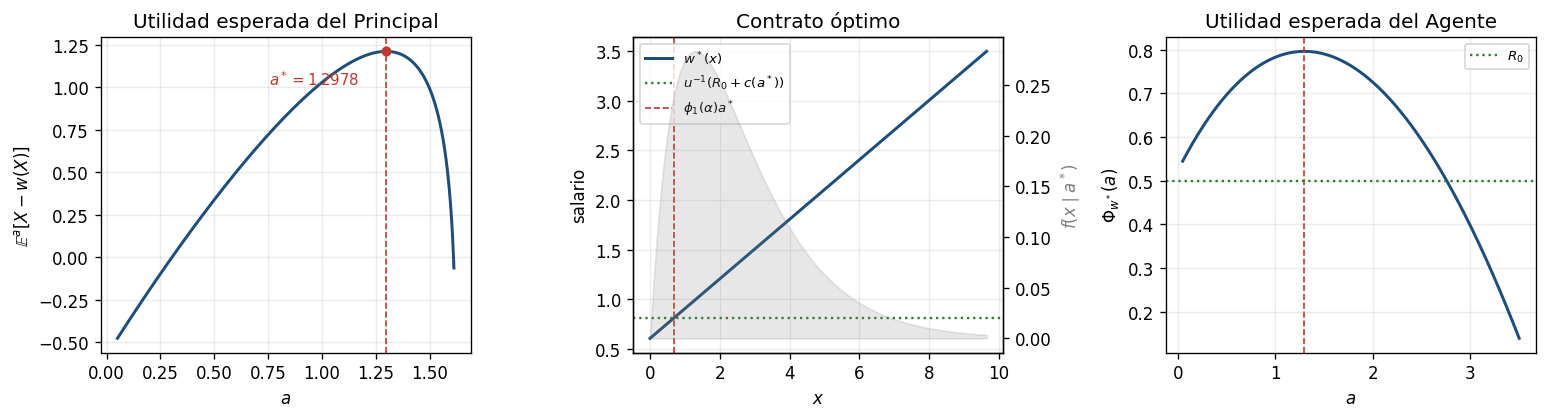

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

m = np.isfinite(sol['value_grid'])
ax[0].plot(sol['a_grid'][m], sol['value_grid'][m], color=COL['main'], lw=1.8)
ax[0].axvline(sol['a'], color=COL['alt'], ls='--', lw=1)
ax[0].plot([sol['a']], [sol['value']], 'o', color=COL['alt'], ms=5)
ax[0].annotate(rf"$a^*={sol['a']:.4f}$", (sol['a'], sol['value']),
               textcoords='offset points', xytext=(-70, -20), color=COL['alt'], fontsize=9)
ax[0].set_xlabel('$a$'); ax[0].set_ylabel(r'$\mathbb{E}^{a}[X-w(X)]$')
ax[0].set_title('Utilidad esperada del Principal')

x = np.linspace(0, gamma_dist.ppf(.995, p['kappa'], scale=sol['a']), 600)
ax[1].plot(x, sol['w0'] + sol['beta']*x, color=COL['main'], lw=1.8, label=r'$w^*(x)$')
ax[1].axhline(u_inv(p['R0'] + cost(sol['a'], p['theta']), p['eta']), color=COL['third'],
              ls=':', lw=1.4, label=r'$u^{-1}(R_0+c(a^*))$')
ax[1].axvline(f1*sol['a'], color=COL['alt'], ls='--', lw=1, label=r'$\phi_1(\alpha)a^*$')
a2 = ax[1].twinx(); a2.grid(False)
a2.set_ylabel(r'$f(x\mid a^*)$', color=COL['grey'])
ax[1].set_xlabel('$x$'); ax[1].set_ylabel('salario')
ax[1].legend(loc='upper left', fontsize=8); ax[1].set_title('Contrato óptimo')

ag = np.linspace(p['a_min'], p['a_max'], 800)
ax[2].plot(ag, Phi(ag, sol['w0'], sol['beta'], p), color=COL['main'], lw=1.8)
ax[2].axvline(sol['a'], color=COL['alt'], ls='--', lw=1)
ax[2].axhline(p['R0'], color=COL['third'], ls=':', lw=1.4, label='$R_0$')
ax[2].set_xlabel('$a$'); ax[2].set_ylabel(r'$\Phi_{w^*}(a)$')
ax[2].legend(fontsize=8); ax[2].set_title('Utilidad esperada del Agente')
fig.tight_layout(); plt.show()

## 6. Más allá del contrato afín

Aquí se explora $W_{\mathrm{conc}}$ de forma genuina. Se fija una grilla $0=x_1<\dots<x_n$ y
las variables pasan a ser los valores $w_i=w(x_i)$, con $w$ lineal a trozos y extrapolación
lineal a la derecha. La monotonía ($w_{i+1}\ge w_i$), la concavidad (pendientes no
crecientes) y la no negatividad son restricciones lineales o cotas simples. Las integrales se
calculan con cuadratura de Gauss--Laguerre generalizada: con $x=at$,
$$\mathbb E[g(X)\mid a]=\int_0^\infty g(at)\frac{t^{\kappa-1}e^{-t}}{\Gamma(\kappa)}\,\mathrm dt
\approx\sum_j\frac{\omega_j}{\Gamma(\kappa)}g(at_j),$$
y para la condición de primer orden se usa el score de la familia de escala,
$\partial_a\log f(x\mid a)=(x-\kappa a)/a^2$. Aquí no existe reducción a una dimensión, de
modo que se recurre a un solver no lineal.

In [9]:
import warnings
from scipy.optimize import minimize
from scipy.special import roots_genlaguerre, gamma as Gamma_fn
warnings.filterwarnings('ignore')

T, OM = roots_genlaguerre(80, p['kappa'] - 1.0); OM = OM / Gamma_fn(p['kappa'])
Eq = lambda g, a: float(np.dot(OM, g(a*T)))
dPhi_q = lambda wf, a: Eq(lambda x: u(wf(x), p['eta'])*(x - p['kappa']*a)/a**2, a) - p['theta']*a

# verificacion de la cuadratura contra las formulas cerradas del contrato afin
print('E[X]      cuadratura', Eq(lambda x: x, sol['a']), '| cerrado', p['kappa']*sol['a'])
print("Phi'(a*)  cuadratura", dPhi_q(lambda x: sol['w0'] + sol['beta']*x, sol['a']),
      '| cerrado', dPhi(sol['a'], sol['w0'], sol['beta'], p))

N, xmax = 20, 12.0
XK = np.concatenate([[0.0], np.geomspace(0.15, xmax, N-1)])

def w_pl(z, wv):
    z = np.atleast_1d(np.asarray(z, float)); y = np.interp(z, XK, wv)
    s = (wv[-1]-wv[-2])/(XK[-1]-XK[-2]); t = z > XK[-1]
    y[t] = wv[-1] + s*(z[t]-XK[-1]); return y

nobj = lambda z: -(p['kappa']*z[-1] - Eq(lambda t: w_pl(t, z[:-1]), z[-1]))
cons = [dict(type='eq',   fun=lambda z: dPhi_q(lambda t: w_pl(t, z[:-1]), z[-1])),
        dict(type='ineq', fun=lambda z: float(w_pl(f1*z[-1], z[:-1])[0]
                                              - u_inv(p['R0']+cost(z[-1], p['theta']), p['eta']))),
        dict(type='ineq', fun=lambda z: np.diff(z[:-1])),
        dict(type='ineq', fun=lambda z: -np.diff(np.diff(z[:-1])/np.diff(XK)))]
z0 = np.concatenate([sol['w0'] + sol['beta']*XK, [sol['a']]])
r = minimize(nobj, z0, method='SLSQP', bounds=[(0., 50.)]*N + [(p['a_min'], p['a_max'])],
             constraints=cons, options=dict(maxiter=1000, ftol=1e-12))
wv, a_pl = r.x[:-1], r.x[-1]

print(f"\ncontrato afin           : a = {sol['a']:.6f}   E[X-w(X)] = {sol['value']:.6f}")
print(f"lineal a trozos concavo : a = {a_pl:.6f}   E[X-w(X)] = {-r.fun:.6f}"
      f"   (+{100*(-r.fun/sol['value']-1):.2f} %)")
print(f"w(0) = {wv[0]:.6f}  ->  la no negatividad "
      f"{'se activa' if wv[0] < 1e-8 else 'esta holgada'}")

E[X]      cuadratura 2.5955865704870615 | cerrado 2.5955865704870544
Phi'(a*)  cuadratura 3.497202527569243e-15 | cerrado 0.0

contrato afin           : a = 1.297793   E[X-w(X)] = 1.211397
lineal a trozos concavo : a = 1.311547   E[X-w(X)] = 1.303686   (+7.62 %)
w(0) = 0.000000  ->  la no negatividad se activa


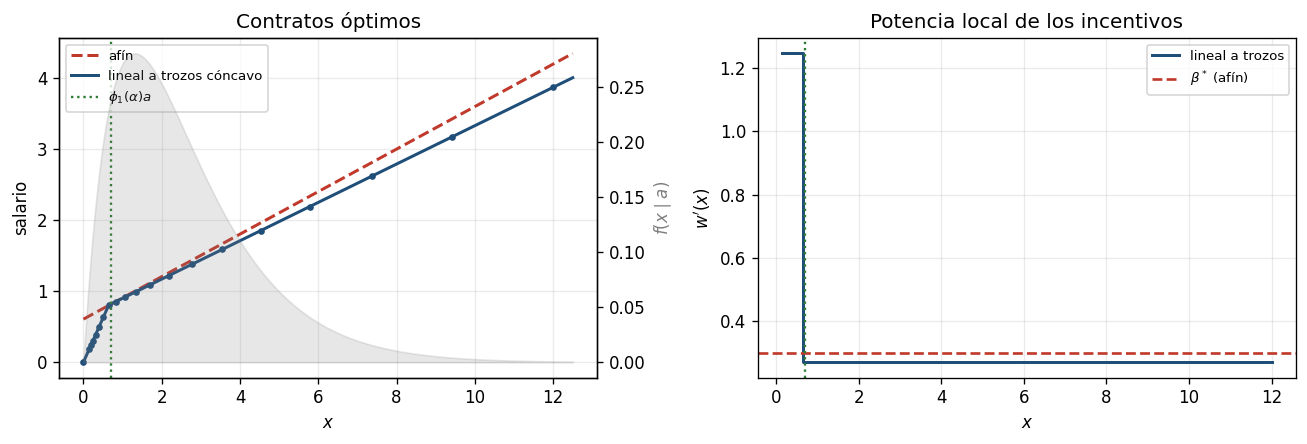

In [10]:
xg = np.linspace(0, 12.5, 800)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].plot(xg, sol['w0'] + sol['beta']*xg, color=COL['alt'], ls='--', lw=1.8, label='afín')
ax[0].plot(xg, w_pl(xg, wv), color=COL['main'], lw=1.8, label='lineal a trozos cóncavo')
ax[0].plot(XK, wv, 'o', color=COL['main'], ms=3)
ax[0].axvline(f1*a_pl, color=COL['third'], ls=':', lw=1.4, label=r'$\phi_1(\alpha)a$')
a2 = ax[0].twinx(); a2.grid(False)
a2.fill_between(xg, gamma_dist.pdf(xg, p['kappa'], scale=a_pl), color=COL['grey'], alpha=.18)
a2.set_ylabel(r'$f(x\mid a)$', color=COL['grey'])
ax[0].set_xlabel('$x$'); ax[0].set_ylabel('salario')
ax[0].legend(loc='upper left', fontsize=8); ax[0].set_title('Contratos óptimos')

sl = np.diff(w_pl(XK, wv))/np.diff(XK)
ax[1].step(XK[1:], sl, where='pre', color=COL['main'], lw=1.8, label='lineal a trozos')
ax[1].axhline(sol['beta'], color=COL['alt'], ls='--', lw=1.6, label=r'$\beta^*$ (afín)')
ax[1].axvline(f1*a_pl, color=COL['third'], ls=':', lw=1.4)
ax[1].set_xlabel('$x$'); ax[1].set_ylabel(r"$w'(x)$")
ax[1].legend(fontsize=8); ax[1].set_title('Potencia local de los incentivos')
fig.tight_layout(); plt.show()

El contrato óptimo dentro de la clase cóncava es esencialmente de dos tramos, con el quiebre
en el cuantil $\phi_1(\alpha)a$: sube desde $w(0)=0$ con pendiente $\approx1.25$ hasta
alcanzar el nivel de reserva y luego se aplana en $\approx0.27$, valor inferior a $\beta^*$.
Liberado de sostener la restricción de participación mediante el salario base, el Principal
concentra los incentivos donde la restricción muerde y los reduce en la cola, que es cara
para un Agente averso al riesgo.